In [1]:
import pandas as pd
from sklearn import datasets
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn import tree

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

In [2]:
# data
boston=pd.read_csv("/content/boston.csv")
boston

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,9.67,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,6.48,22.0


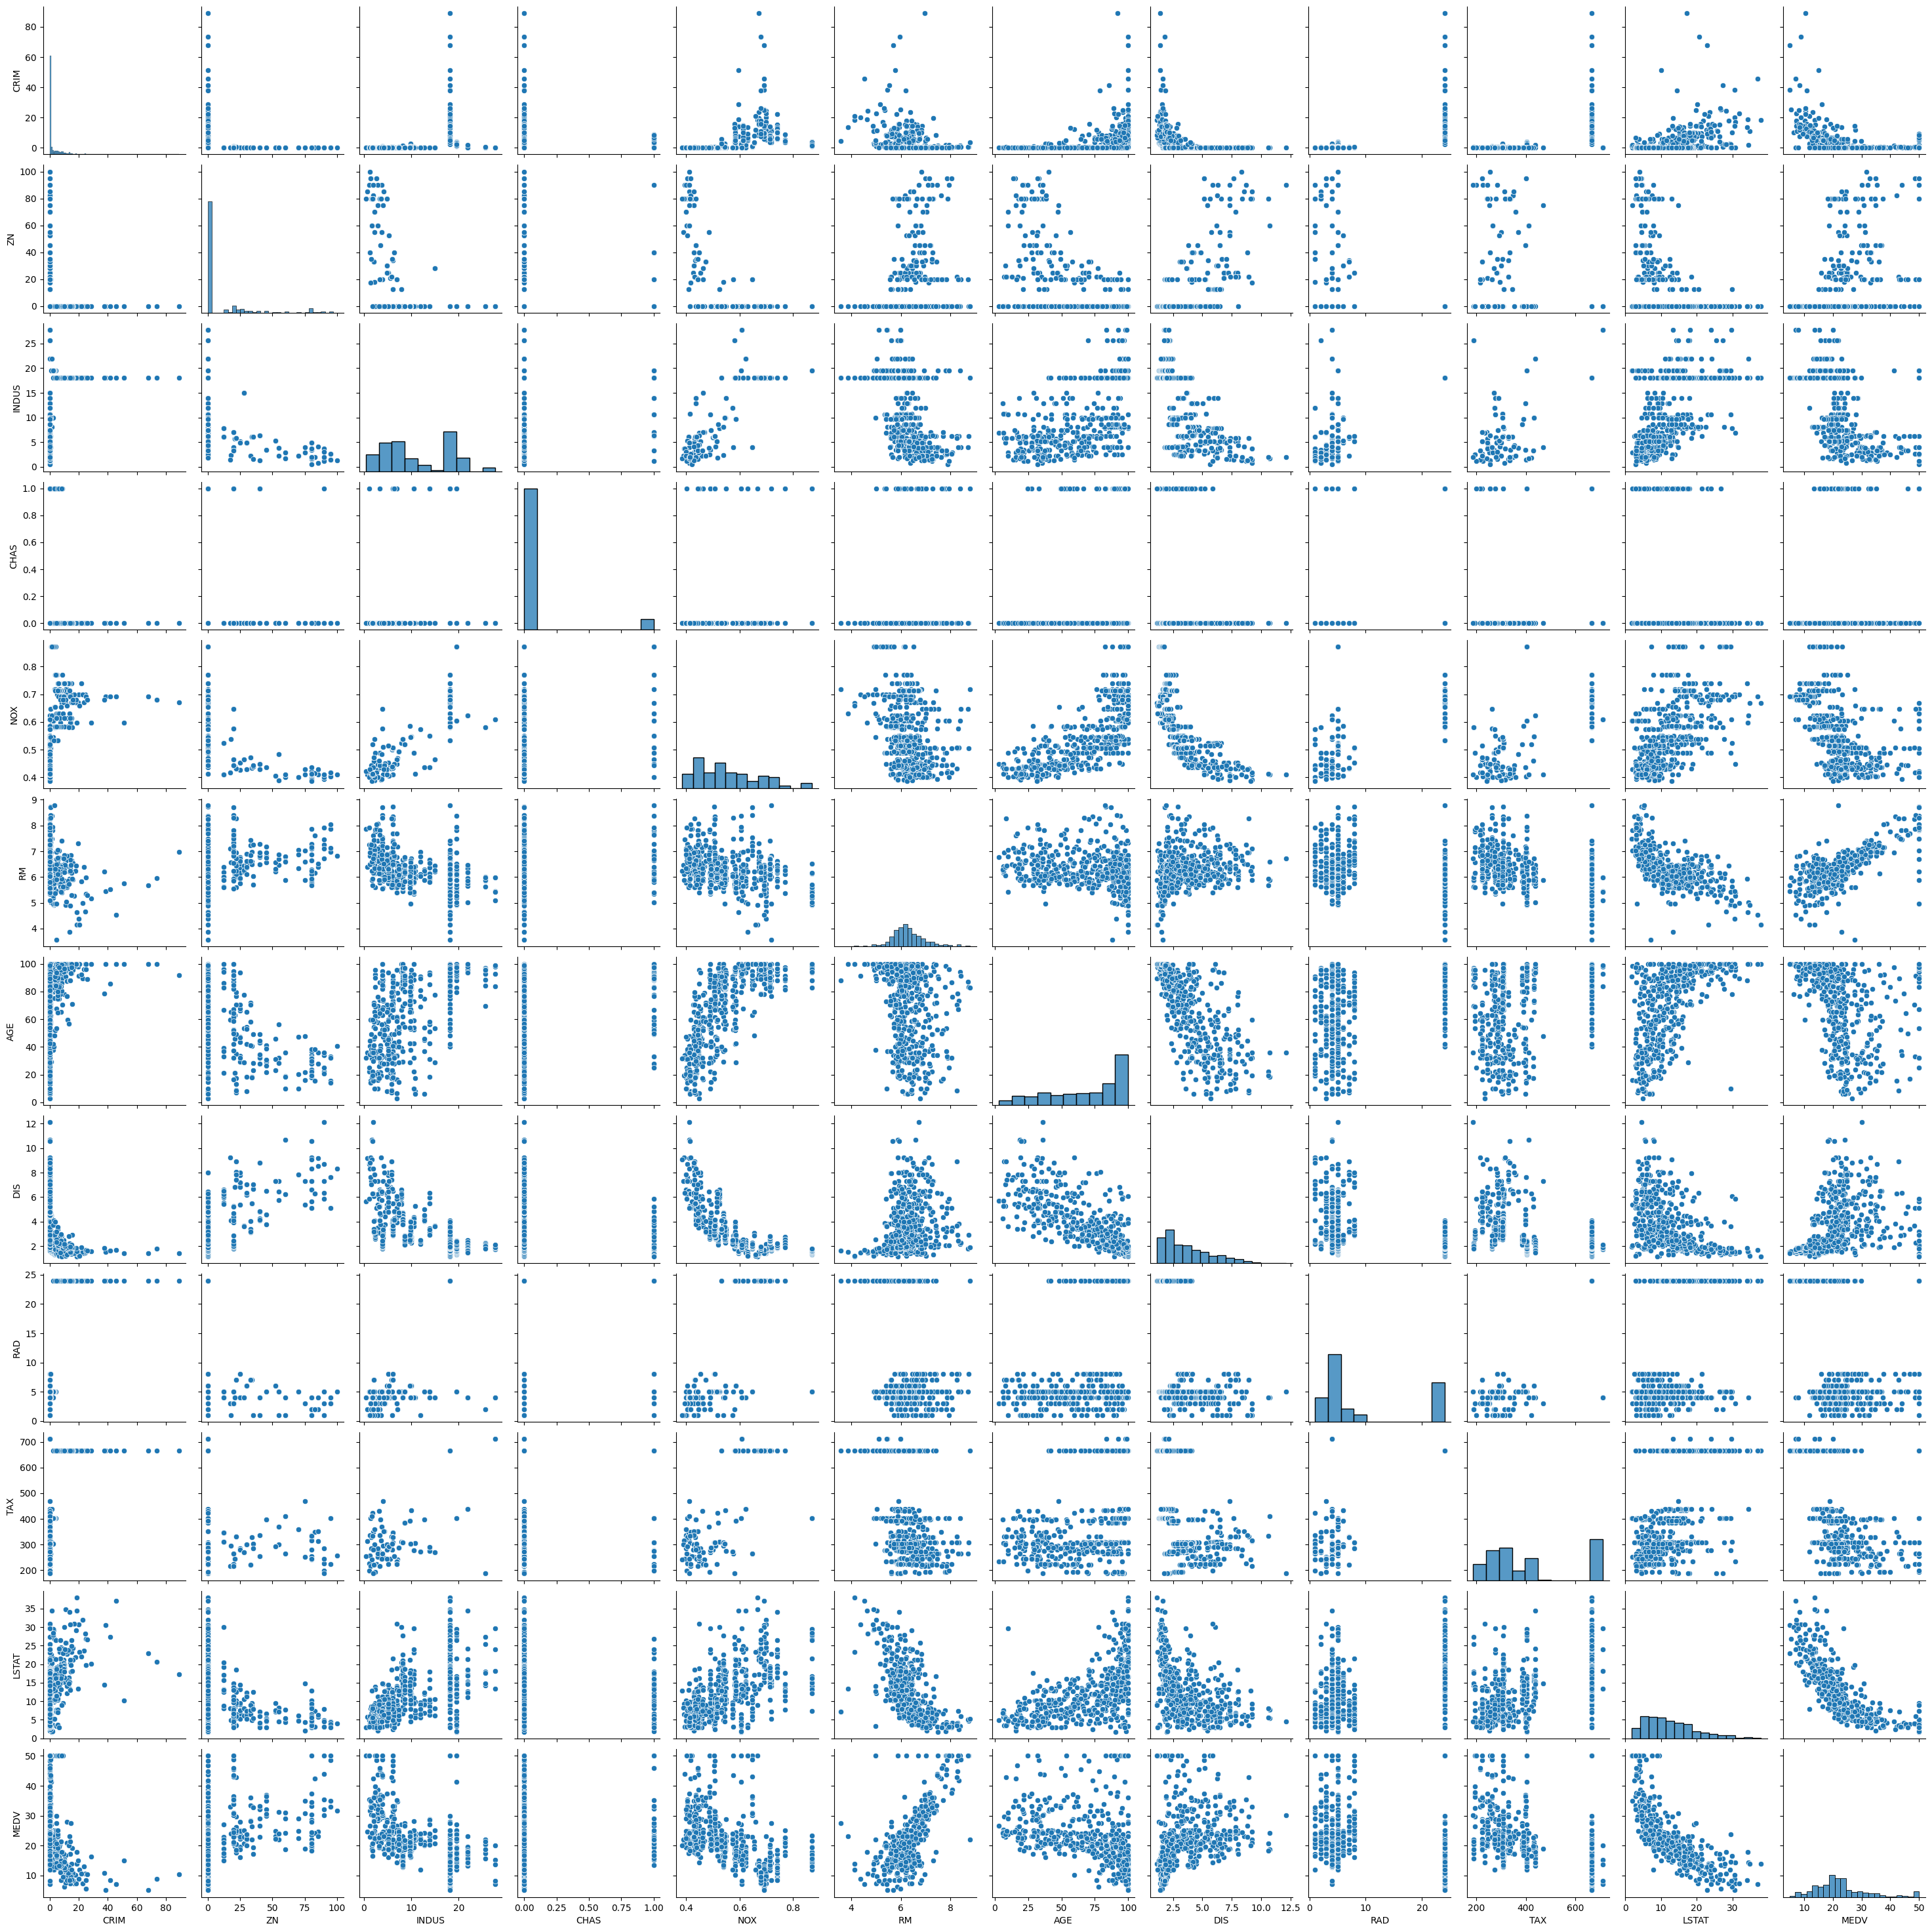

In [ ]:
sns.pairplot(boston)

In [3]:
# X variables and Y variable, split in train and test
X=boston.drop("MEDV",axis=1)
y=boston["MEDV"]
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2)

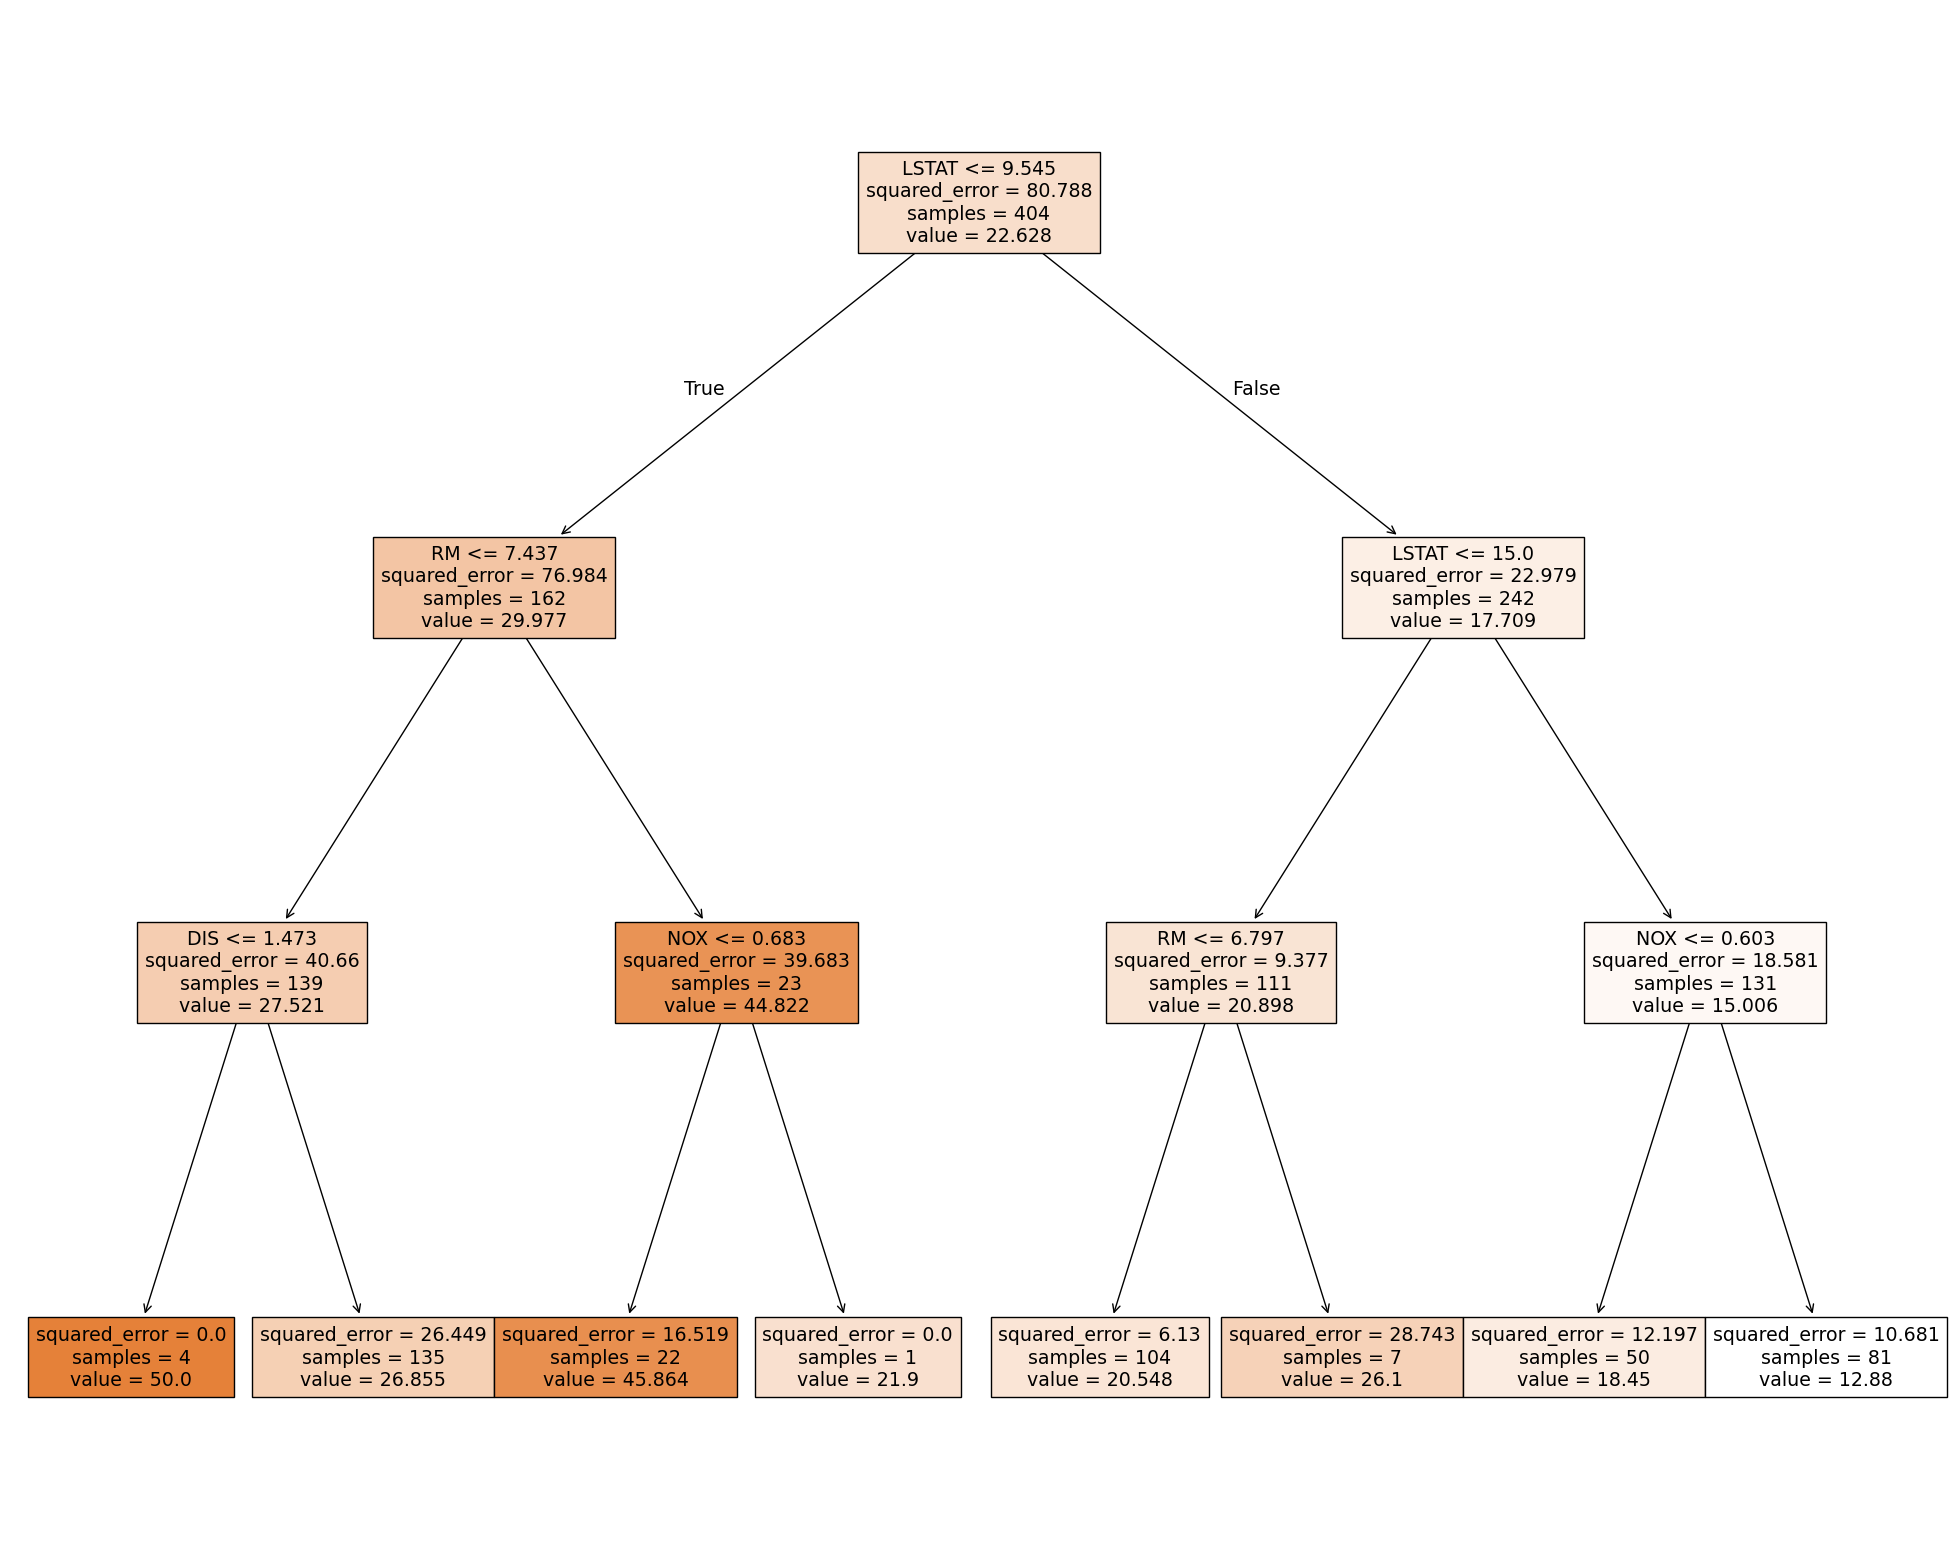

In [4]:
regr=DecisionTreeRegressor(max_depth=3)
modelo=regr.fit(Xtrain,ytrain)

fig=plt.figure(figsize=(25,20))
tree.plot_tree(modelo,feature_names=X.columns,filled=True)
plt.show()

In [5]:
# Cross-validation using regression tree
regr=DecisionTreeRegressor(max_depth=3)
scores=cross_val_score(regr,Xtrain,ytrain,cv=5)
scores.mean(), scores.std()

(np.float64(0.7085850971664506), np.float64(0.15527158595374793))

In [6]:
# Cross-validation using Random Forest

regr2=RandomForestRegressor(max_depth=3)
scores=cross_val_score(regr2,Xtrain,ytrain,cv=5)
scores.mean(), scores.std()

(np.float64(0.8020920578076989), np.float64(0.02730252910684743))

In [7]:
#Train the best algorithm with the complete training set

regr2=RandomForestRegressor(max_depth=3)
modelo2=regr2.fit(Xtrain, ytrain)
print("RF performance with training set: ",modelo2.score(Xtrain,ytrain))
print("RF performance with test set: ",modelo2.score(Xtest,ytest))

RF performance with training set:  0.873671874183274
RF performance with test set:  0.8502989063511361


In [8]:
regr2.predict(Xtest)

array([19.78336156, 21.23949481, 14.34598271, 22.82327908, 21.31806695,
       26.04819705, 15.93967044, 14.87845182, 21.01896055, 22.49034151,
       23.46425392, 21.40242095, 23.46425392, 33.09991539, 28.82724364,
       21.31806695, 12.20132502, 23.67359615, 24.60721918, 30.42851076,
       13.31457421, 21.23949481, 17.25358693, 45.24766531, 23.52386076,
       41.47436661, 28.82230427, 42.17397904, 45.35697386, 25.88004855,
       24.93312897, 24.63585236, 45.88267332, 21.01896055, 21.31806695,
       17.7740531 , 14.28571535, 21.23949481, 39.80939535, 19.78153288,
       25.167485  , 14.55185308, 17.25358693, 15.10340548, 17.57956398,
       13.05075327, 18.14600284, 12.14902679, 15.83521704, 20.78221144,
       24.63585236, 21.23949481, 24.63585236, 28.63598133, 20.78056791,
       14.5906275 , 24.35293163, 12.25088115, 11.90854515, 23.62984638,
       20.75267207, 18.66676291, 12.25808071, 15.54340131, 21.23949481,
       16.22891279, 15.42433177, 11.90854515, 23.953442  , 25.09

In [9]:
print("\n-Decision Tree Regressor Tuning-")
dt_regressor = DecisionTreeRegressor(random_state=42)
dt_param_grid = {'max_depth': [3, 5, 10, 15, None]}


-Decision Tree Regressor Tuning-


In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn import tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# scoring='r2' is used here to be consistent with the .score() method
dt_grid_search = GridSearchCV(dt_regressor, dt_param_grid, cv=5, scoring='r2', n_jobs=-1)
dt_grid_search.fit(Xtrain, ytrain)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 10, 15, None]}, scoring='r2')

In [13]:
best_dt_r2_cv = dt_grid_search.best_score_
best_dt_params = dt_grid_search.best_params_
best_dt = dt_grid_search.best_estimator_
test_dt_r2 = best_dt.score(Xtest, ytest)

print(f"Optimal max_depth for Decision Tree: {best_dt_params['max_depth']}")
print(f"Best Cross-Validated R2 (Decision Tree): {best_dt_r2_cv:.4f}")
print(f"Test R2 with optimal Decision Tree: {test_dt_r2:.4f}")

Optimal max_depth for Decision Tree: 3
Best Cross-Validated R2 (Decision Tree): 0.7100
Test R2 with optimal Decision Tree: 0.7755


In [14]:
regr_orig = DecisionTreeRegressor(max_depth=3, random_state=42)
scores_orig_dt = cross_val_score(regr_orig, Xtrain, ytrain, cv=5)
print(f"Original Decision Tree (max_depth=3) Cross-Validated R2: {scores_orig_dt.mean():.4f}, Std: {scores_orig_dt.std():.4f}")


Original Decision Tree (max_depth=3) Cross-Validated R2: 0.7100, Std: 0.1539


Conclusions:

-Max depth 3 was found to be the best performing model based on the cross validation process.

- CROSS_ VALIDATED R2(Decision Tree) - No change was seen in the R2 with the hypertunning more than likly becuase the max_depth remained the same as the original

-Test R2 with optimal Decision Tree: 0.7755 means the model is taining on the entire traning set adn then evaluated on a completely independent test set. So in this case 77.55% of the variance in the target variable on unseen data.



In [16]:
# Random Forest with Hyperparameter Tuning
print("\n-Random Forest Regressor Tuning-")
rf_regressor = RandomForestRegressor(random_state=42)
rf_param_grid = {
    'n_estimators': [50, 100, 200],  # Common values to tune
    'max_depth': [10, 20, None],
}

rf_grid_search = GridSearchCV(rf_regressor, rf_param_grid, cv=5, scoring='r2', n_jobs=-1)
rf_grid_search.fit(Xtrain, ytrain)

best_rf_r2_cv = rf_grid_search.best_score_
best_rf_params = rf_grid_search.best_params_
best_rf = rf_grid_search.best_estimator_
test_rf_r2 = best_rf.score(Xtest, ytest)

print(f"Optimal hyperparameters for Random Forest: {best_rf_params}")
print(f"Best Cross-Validated R2 (Random Forest): {best_rf_r2_cv:.4f}")
print(f"Test R2 with optimal Random Forest: {test_rf_r2:.4f}")


-Random Forest Regressor Tuning-
Optimal hyperparameters for Random Forest: {'max_depth': None, 'n_estimators': 200}
Best Cross-Validated R2 (Random Forest): 0.8392
Test R2 with optimal Random Forest: 0.9144


Conclusions:

For Optimal Hyperparameters:
max_depth: None (Trees grow to full depth).
n_estimators: 200 (Number of decision trees in the forest).

Best Cross-Validated R2: 0.8392
This indicates the average performance on unseen data during tuning, explaining ~83.92% of variance.

Test R2 with Optimal Random Forest: 0.9144
Performance on a completely independent test set, explaining ~91.44% of variance.

Take aways:
Hyperparameter tuning significantly improved performance compared to the Decision Tree (R2 0.7100).

The Random Forest model generalizes exceptionally well to new data.

In [17]:
#KNN Implementation and Analysis

print("\n--- KNN Regressor with Scaling and Tuning ---")
# scaling the data for KNN
scaler = StandardScaler()
Xtrain_scaled = scaler.fit_transform(Xtrain)
Xtest_scaled = scaler.transform(Xtest)

knn_regressor = KNeighborsRegressor()
knn_param_grid = {'n_neighbors': np.arange(1, 21)}

knn_grid_search = GridSearchCV(knn_regressor, knn_param_grid, cv=5, scoring='r2', n_jobs=-1)
knn_grid_search.fit(Xtrain_scaled, ytrain)

best_knn_r2_cv = knn_grid_search.best_score_
best_knn_params = knn_grid_search.best_params_
best_knn = knn_grid_search.best_estimator_
test_knn_r2 = best_knn.score(Xtest_scaled, ytest)

print(f"Optimal n_neighbors (k) for KNN: {best_knn_params['n_neighbors']}")
print(f"Best Cross-Validated R2 (KNN): {best_knn_r2_cv:.4f}")
print(f"Test R2 with optimal KNN: {test_knn_r2:.4f}")


--- KNN Regressor with Scaling and Tuning ---
Optimal n_neighbors (k) for KNN: 7
Best Cross-Validated R2 (KNN): 0.7037
Test R2 with optimal KNN: 0.8025


Conlusions:

- The KNN model performs better than the single Decision Tree (R2 of 0.7755) on the test set but is still less accurate than the Random Forest (R2 of 0.9144).

-(k)7 : The tuning process found that using 7 of the nearest data points to make a prediction resulted in the best average performance during cross-validation.

--Best Cross-Validated R2: 0.7037 70.37% of the target variable's variance on data it hasn't trained on. Which is less than the Hyoertuning found on the random forest.

Overall, bettet than the decision tree but not as good as Random Forest with Hyperparameter Tuning.
